In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# testing with noise factor 0.3

resnet_metrics_factor03={
    "Fold 1": {"PSNR": 31.65, "SSIM": 0.8459, "EPI": 0.3972},
    "Fold 2": {"PSNR": 31.10, "SSIM": 0.8211, "EPI": 0.4014},
    "Fold 3": {"PSNR": 30.75, "SSIM": 0.8202, "EPI": 0.2753},
    "Fold 4": {"PSNR": 30.94, "SSIM": 0.8225, "EPI": 0.3417},
    "Fold 5": {"PSNR": 31.40, "SSIM": 0.8453, "EPI": 0.3921}
}

# noise factor 0.4

resnet_metrics_factor04={
    "Fold 1": {"PSNR": 26.82, "SSIM": 0.6280, "EPI": 0.2334},
    "Fold 2": {"PSNR": 26.96, "SSIM": 0.625 , "EPI": 0.2459},
    "Fold 3": {"PSNR": 25.53, "SSIM": 0.5812, "EPI": 0.1353},
    "Fold 4": {"PSNR": 24.97, "SSIM": 0.5342, "EPI": 0.1489},
    "Fold 5": {"PSNR": 28.17, "SSIM": 0.6942, "EPI": 0.274 }
}

resnet_metrics_factor02={
    "Fold 1": {"PSNR": 28.45, "SSIM": 0.4738, "EPI": 0.3812},
    "Fold 2": {"PSNR": 30.10, "SSIM": 0.7122, "EPI": 0.4264},
    "Fold 3": {"PSNR": 27.12, "SSIM": 0.3954, "EPI": 0.2151},
    "Fold 4": {"PSNR": 27.84, "SSIM": 0.4378, "EPI": 0.3023},
    "Fold 5": {"PSNR": 28.16, "SSIM": 0.4904, "EPI": 0.3458}
}

In [3]:
all_data = {
    "0.2": resnet_metrics_factor02,
    "0.3": resnet_metrics_factor03,
    "0.4": resnet_metrics_factor04,
}

metrics = ["PSNR", "SSIM", "EPI"]
folds = list(resnet_metrics_factor02.keys())

In [4]:
folds

['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

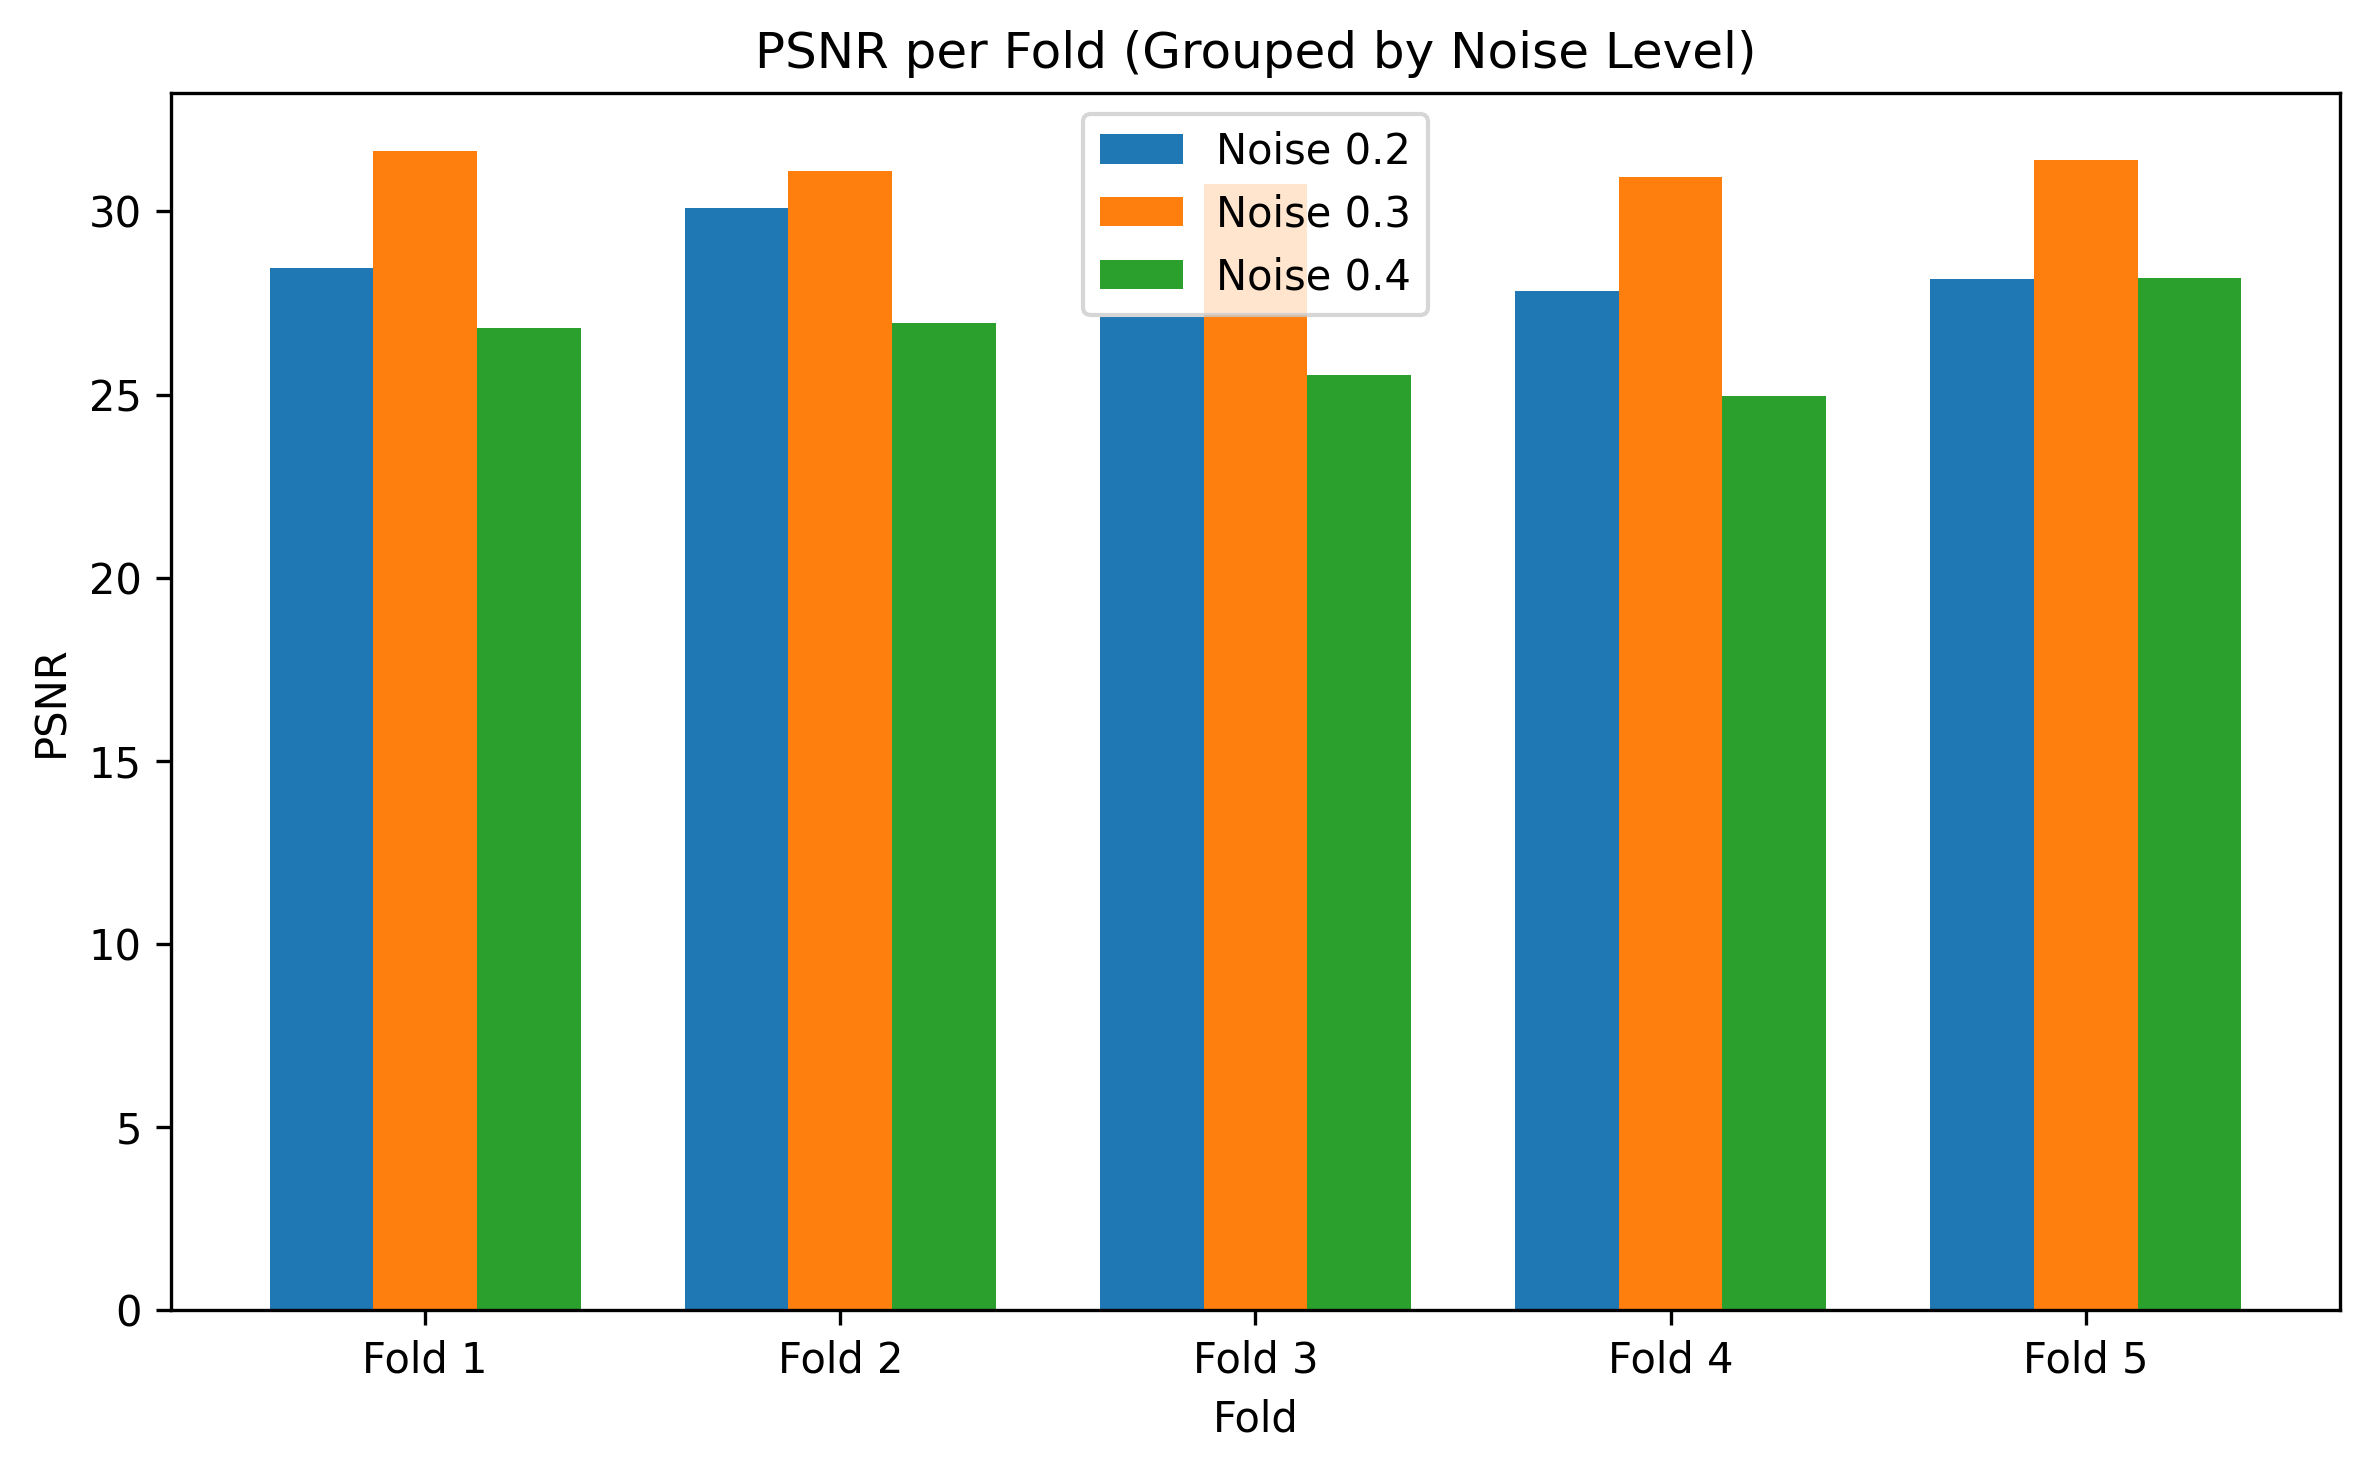

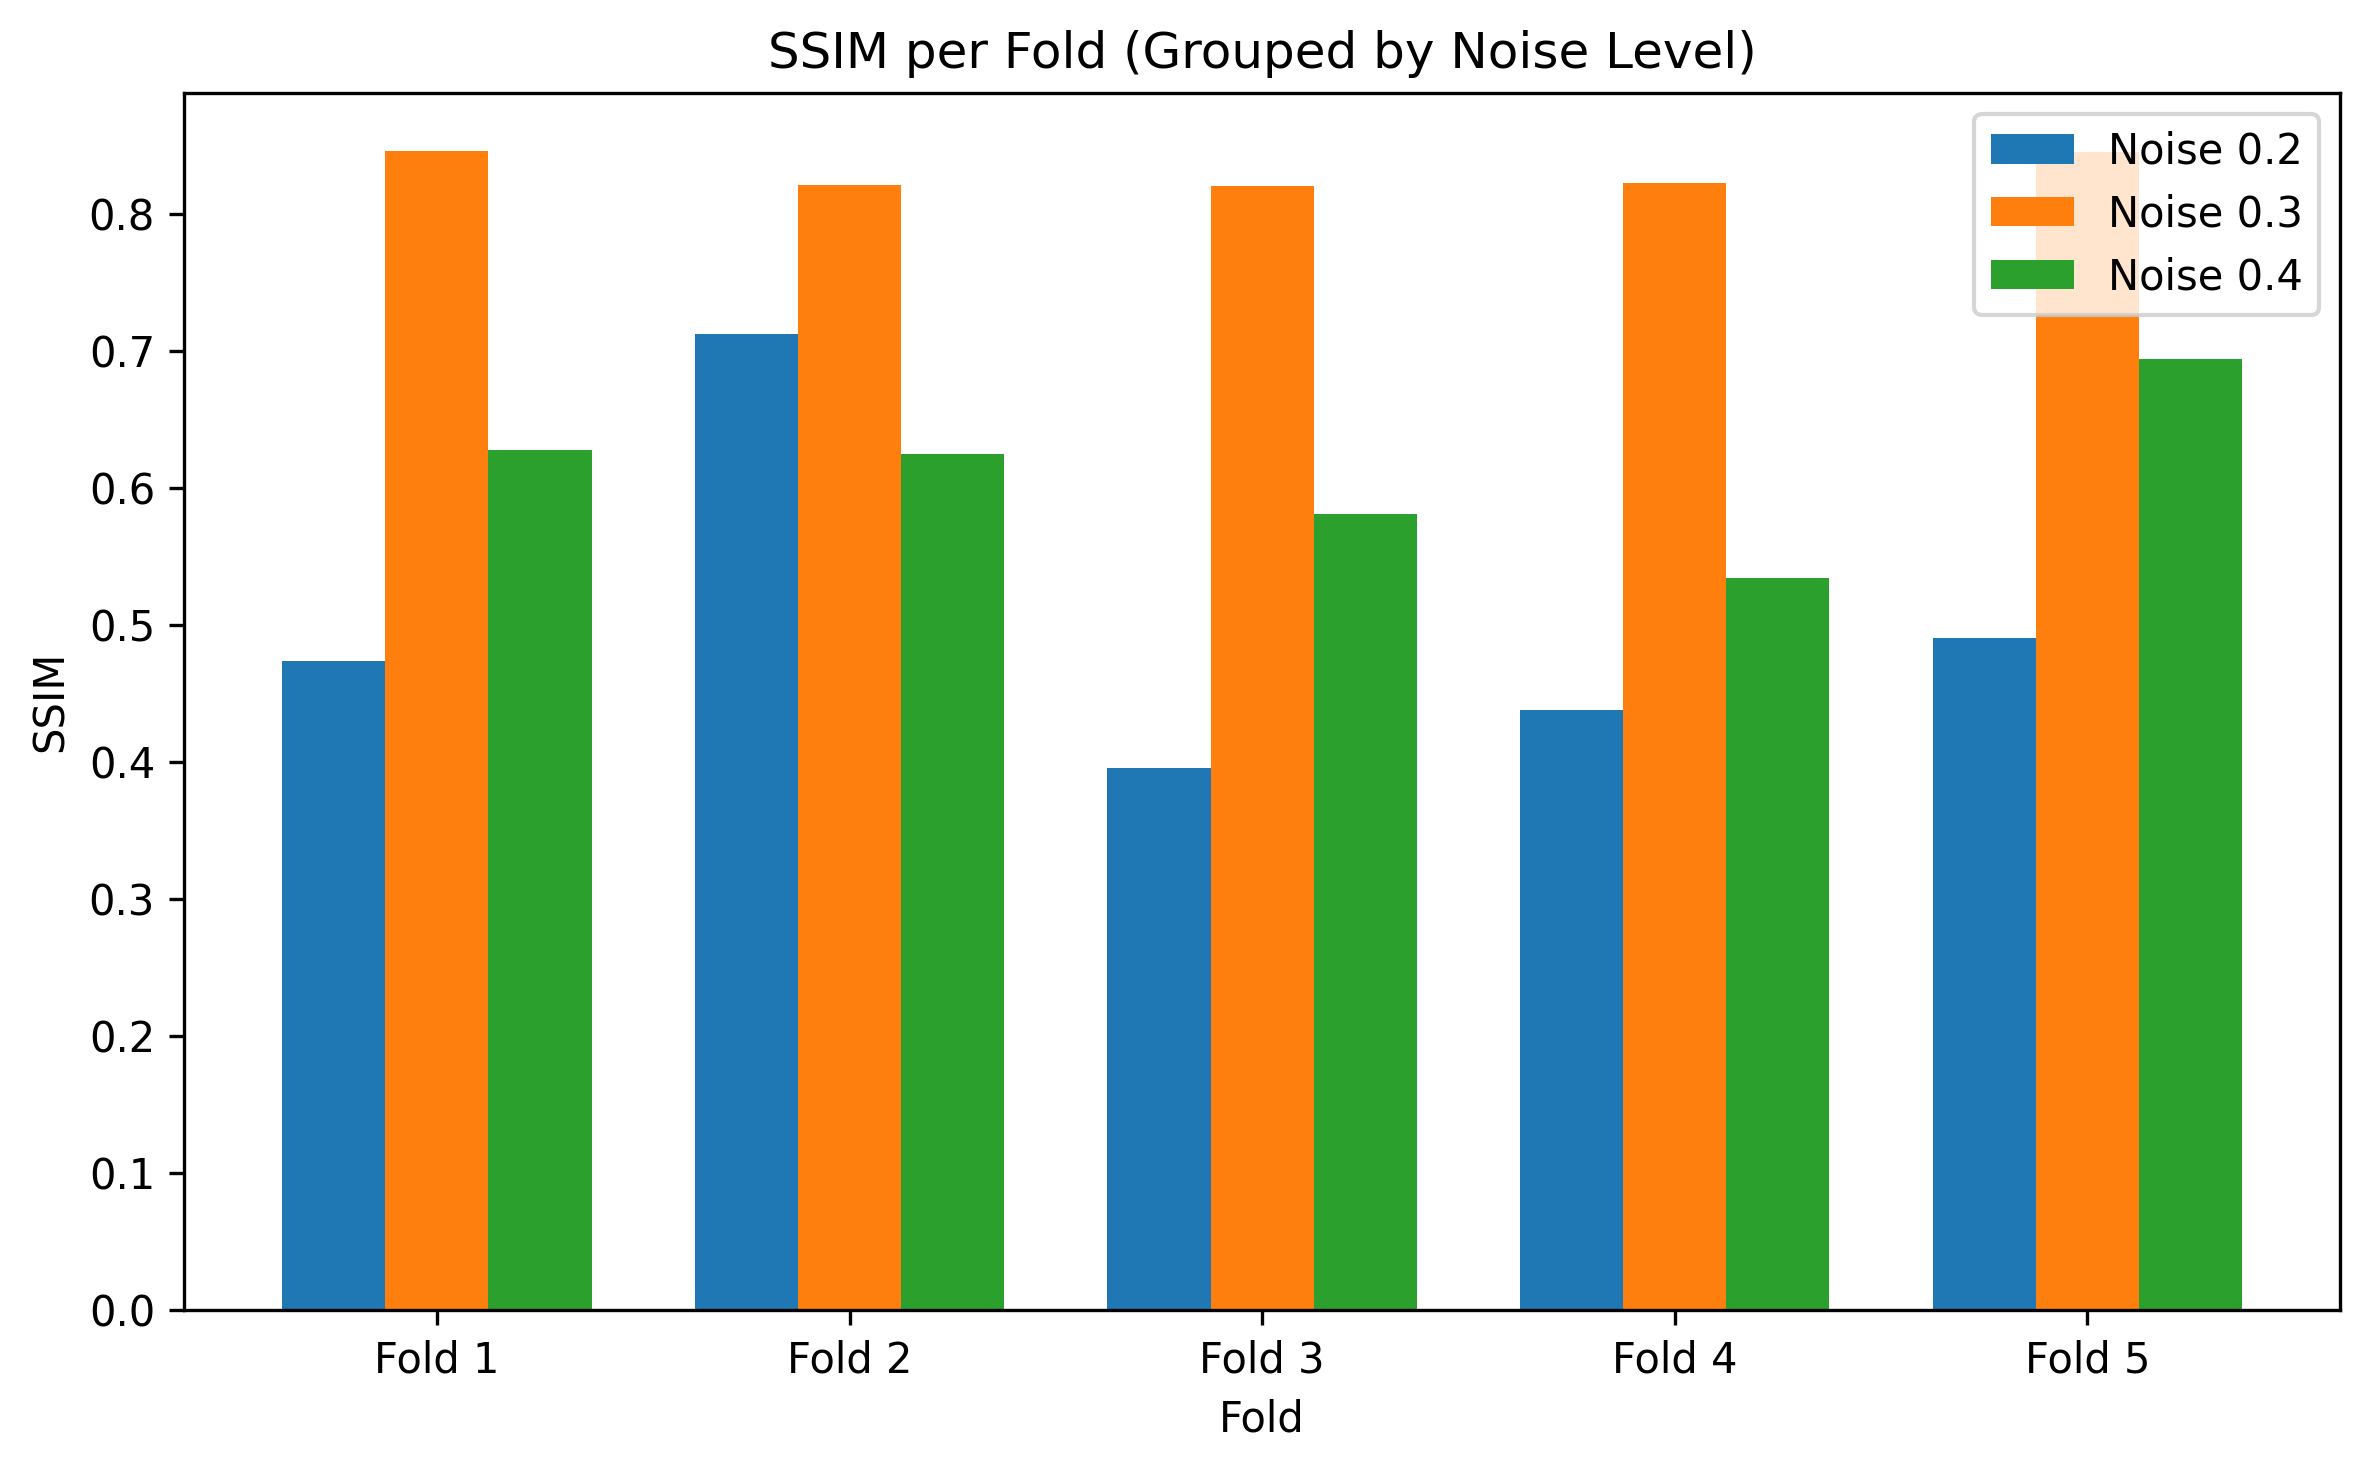

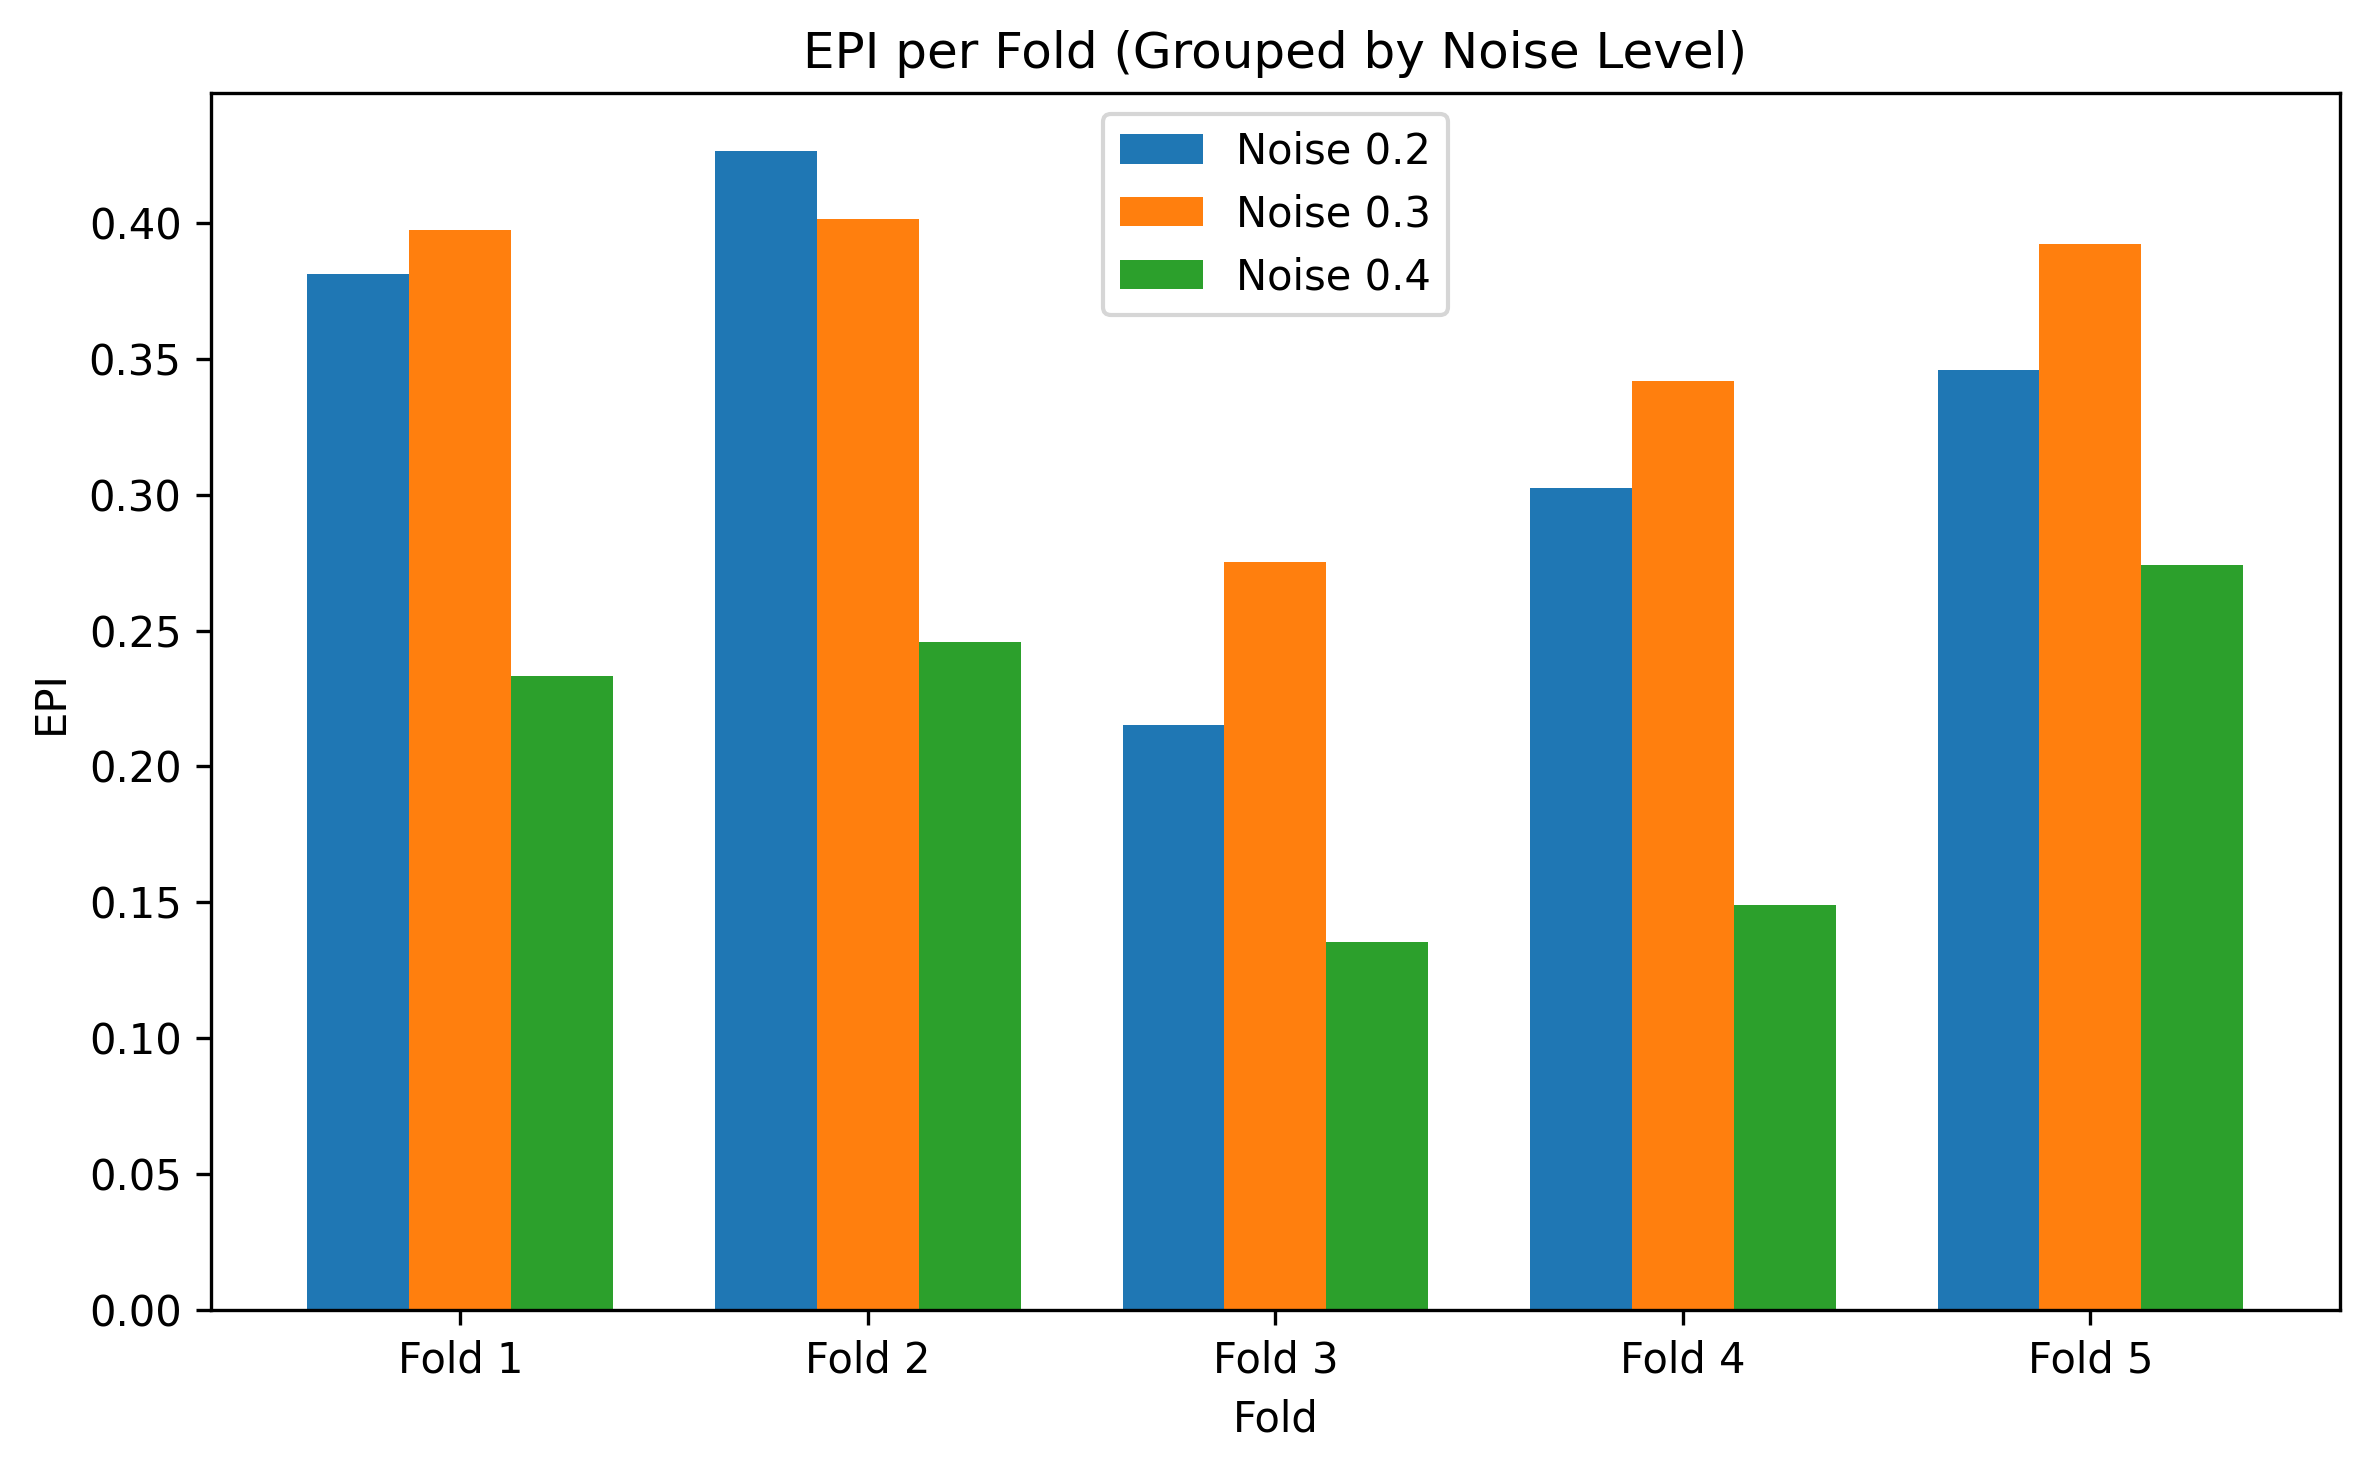

In [5]:

for metric in metrics:
    plt.figure(figsize=(8,5), dpi=300)

    x = np.arange(len(folds))
    width = 0.25
    i = 0

    for noise, data in all_data.items():
        values = [data[fold][metric] for fold in folds]
        plt.bar(x + i*width, values, width=width, label=f"Noise {noise}")
        i += 1

    plt.xticks(x + width, folds)
    plt.title(f"{metric} per Fold (Grouped by Noise Level)")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

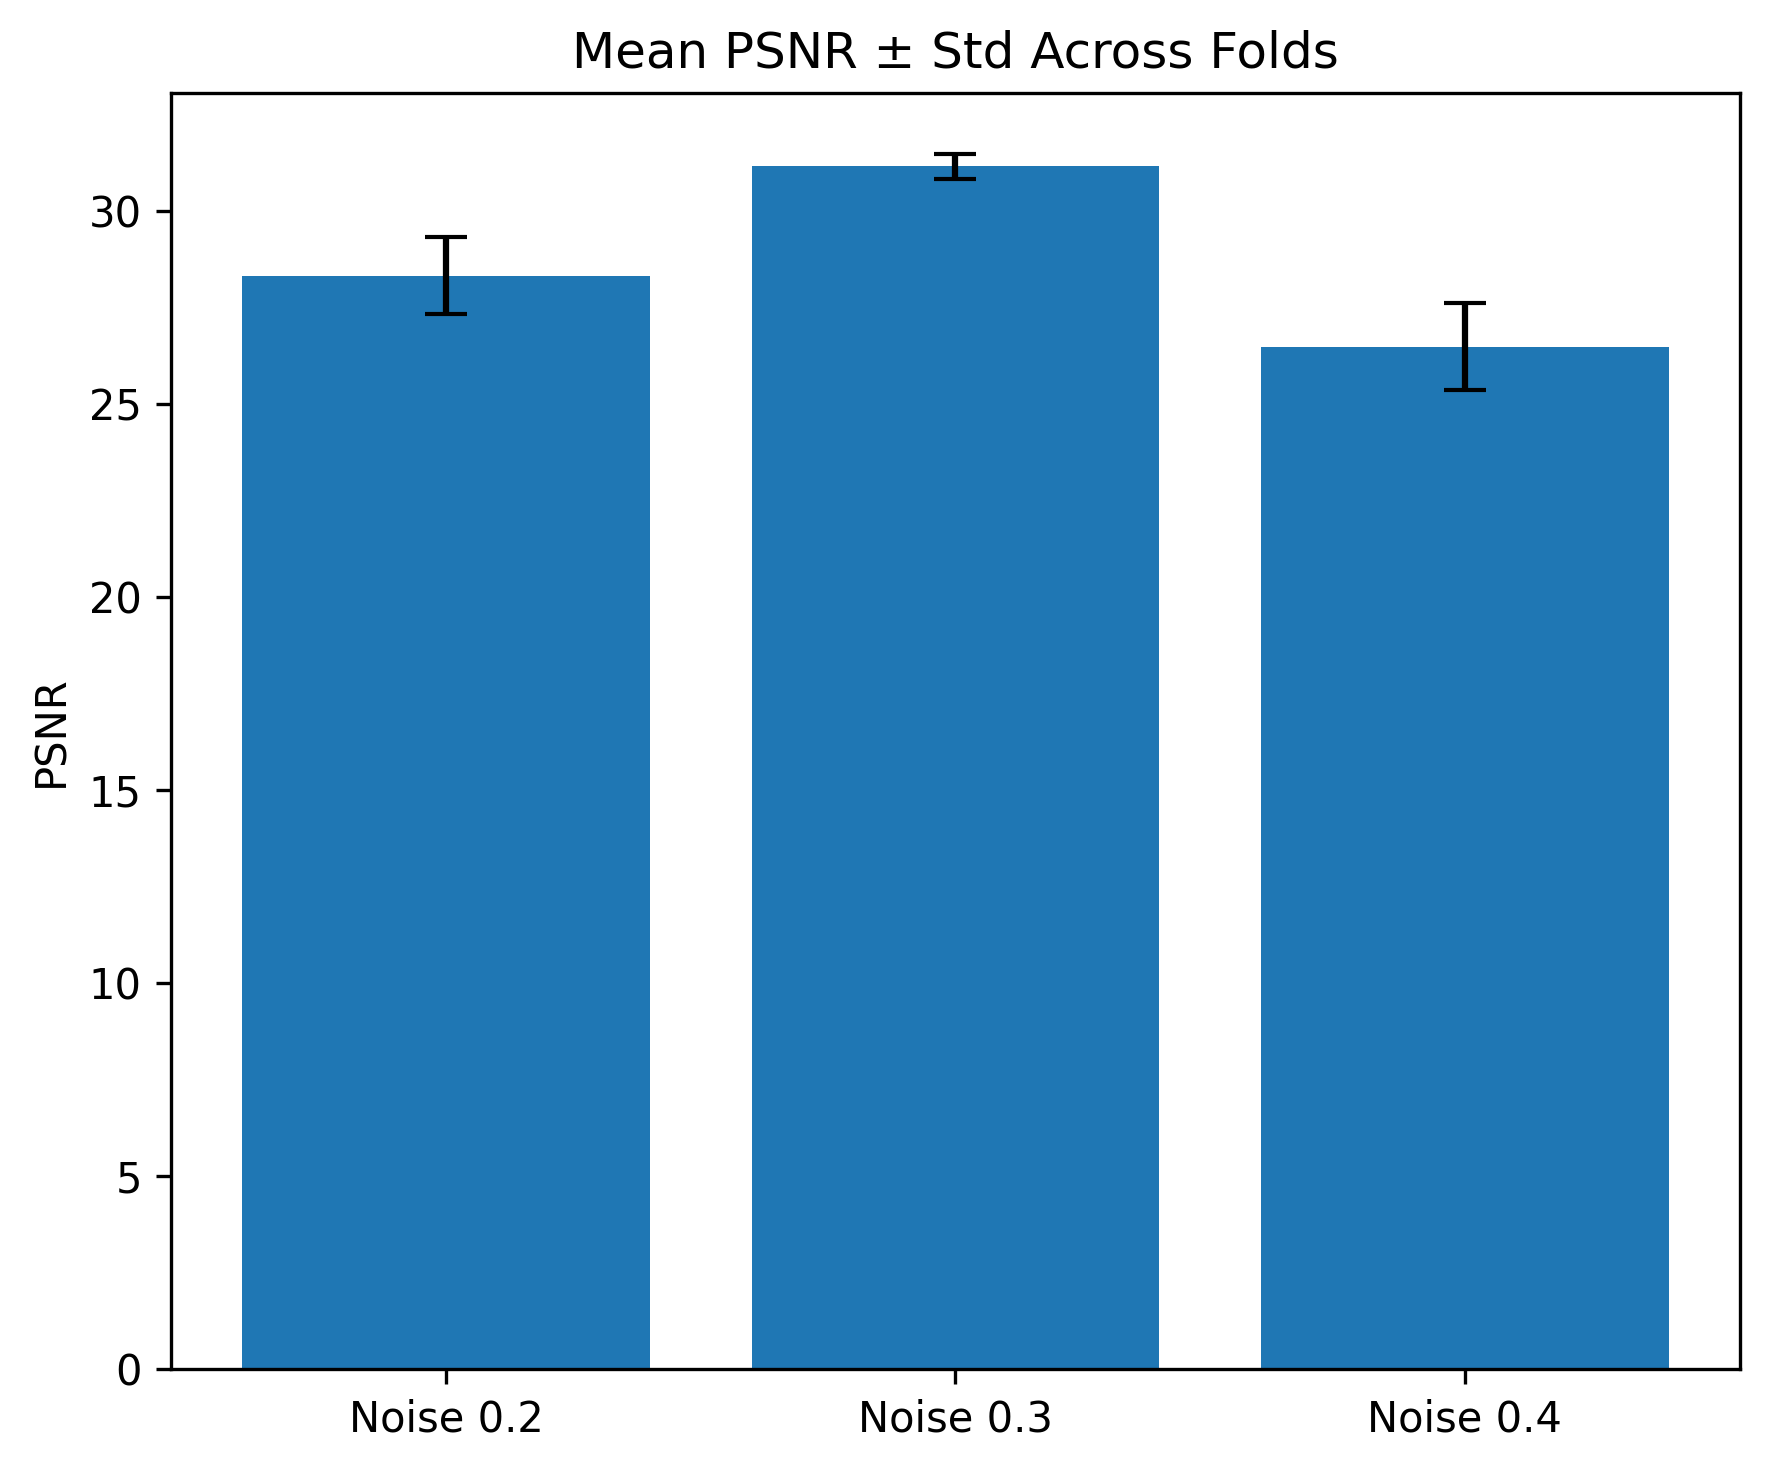

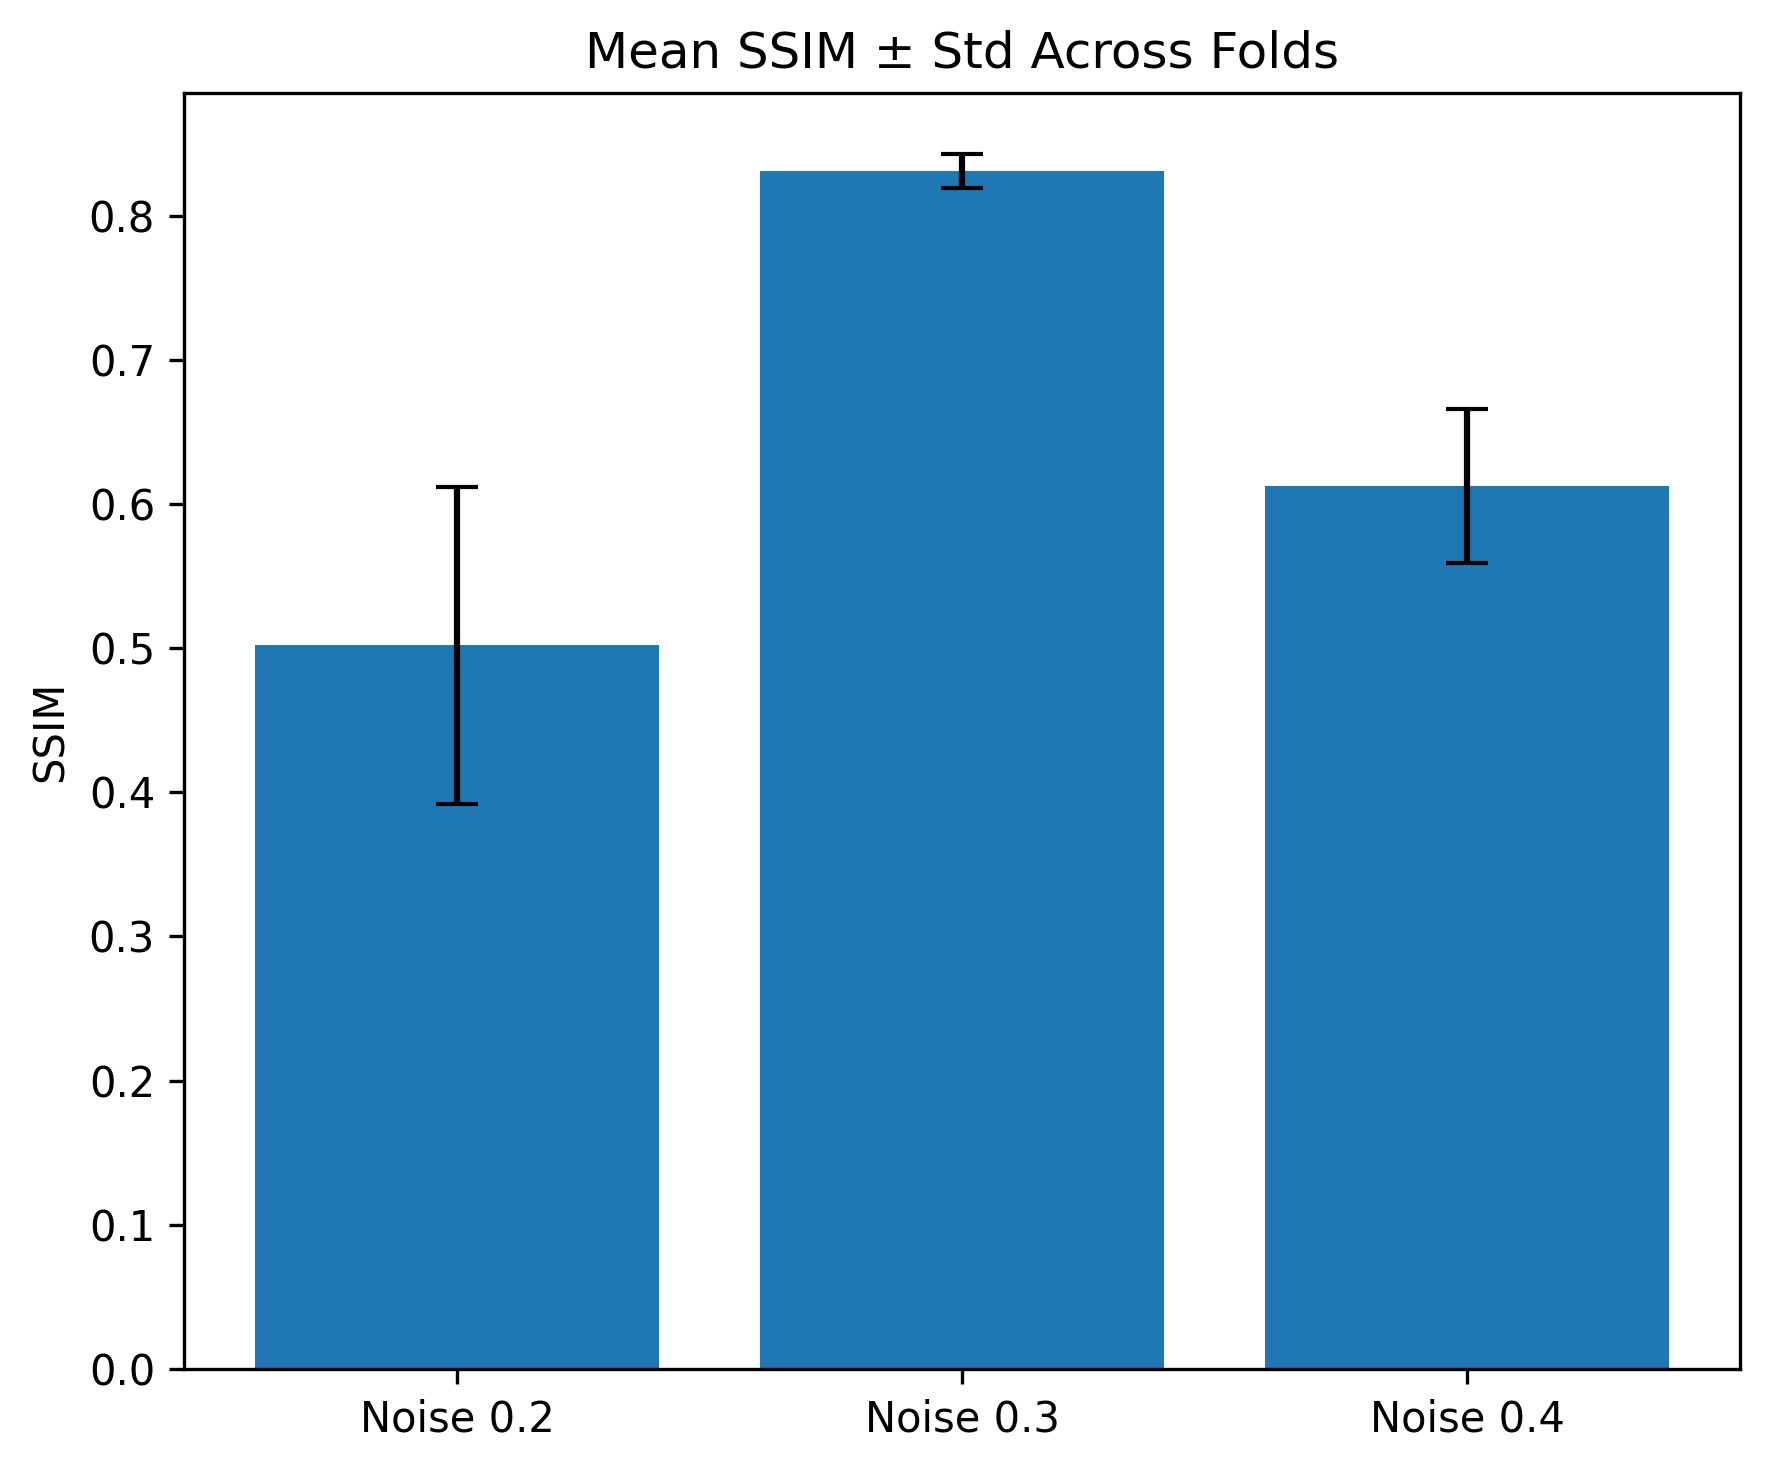

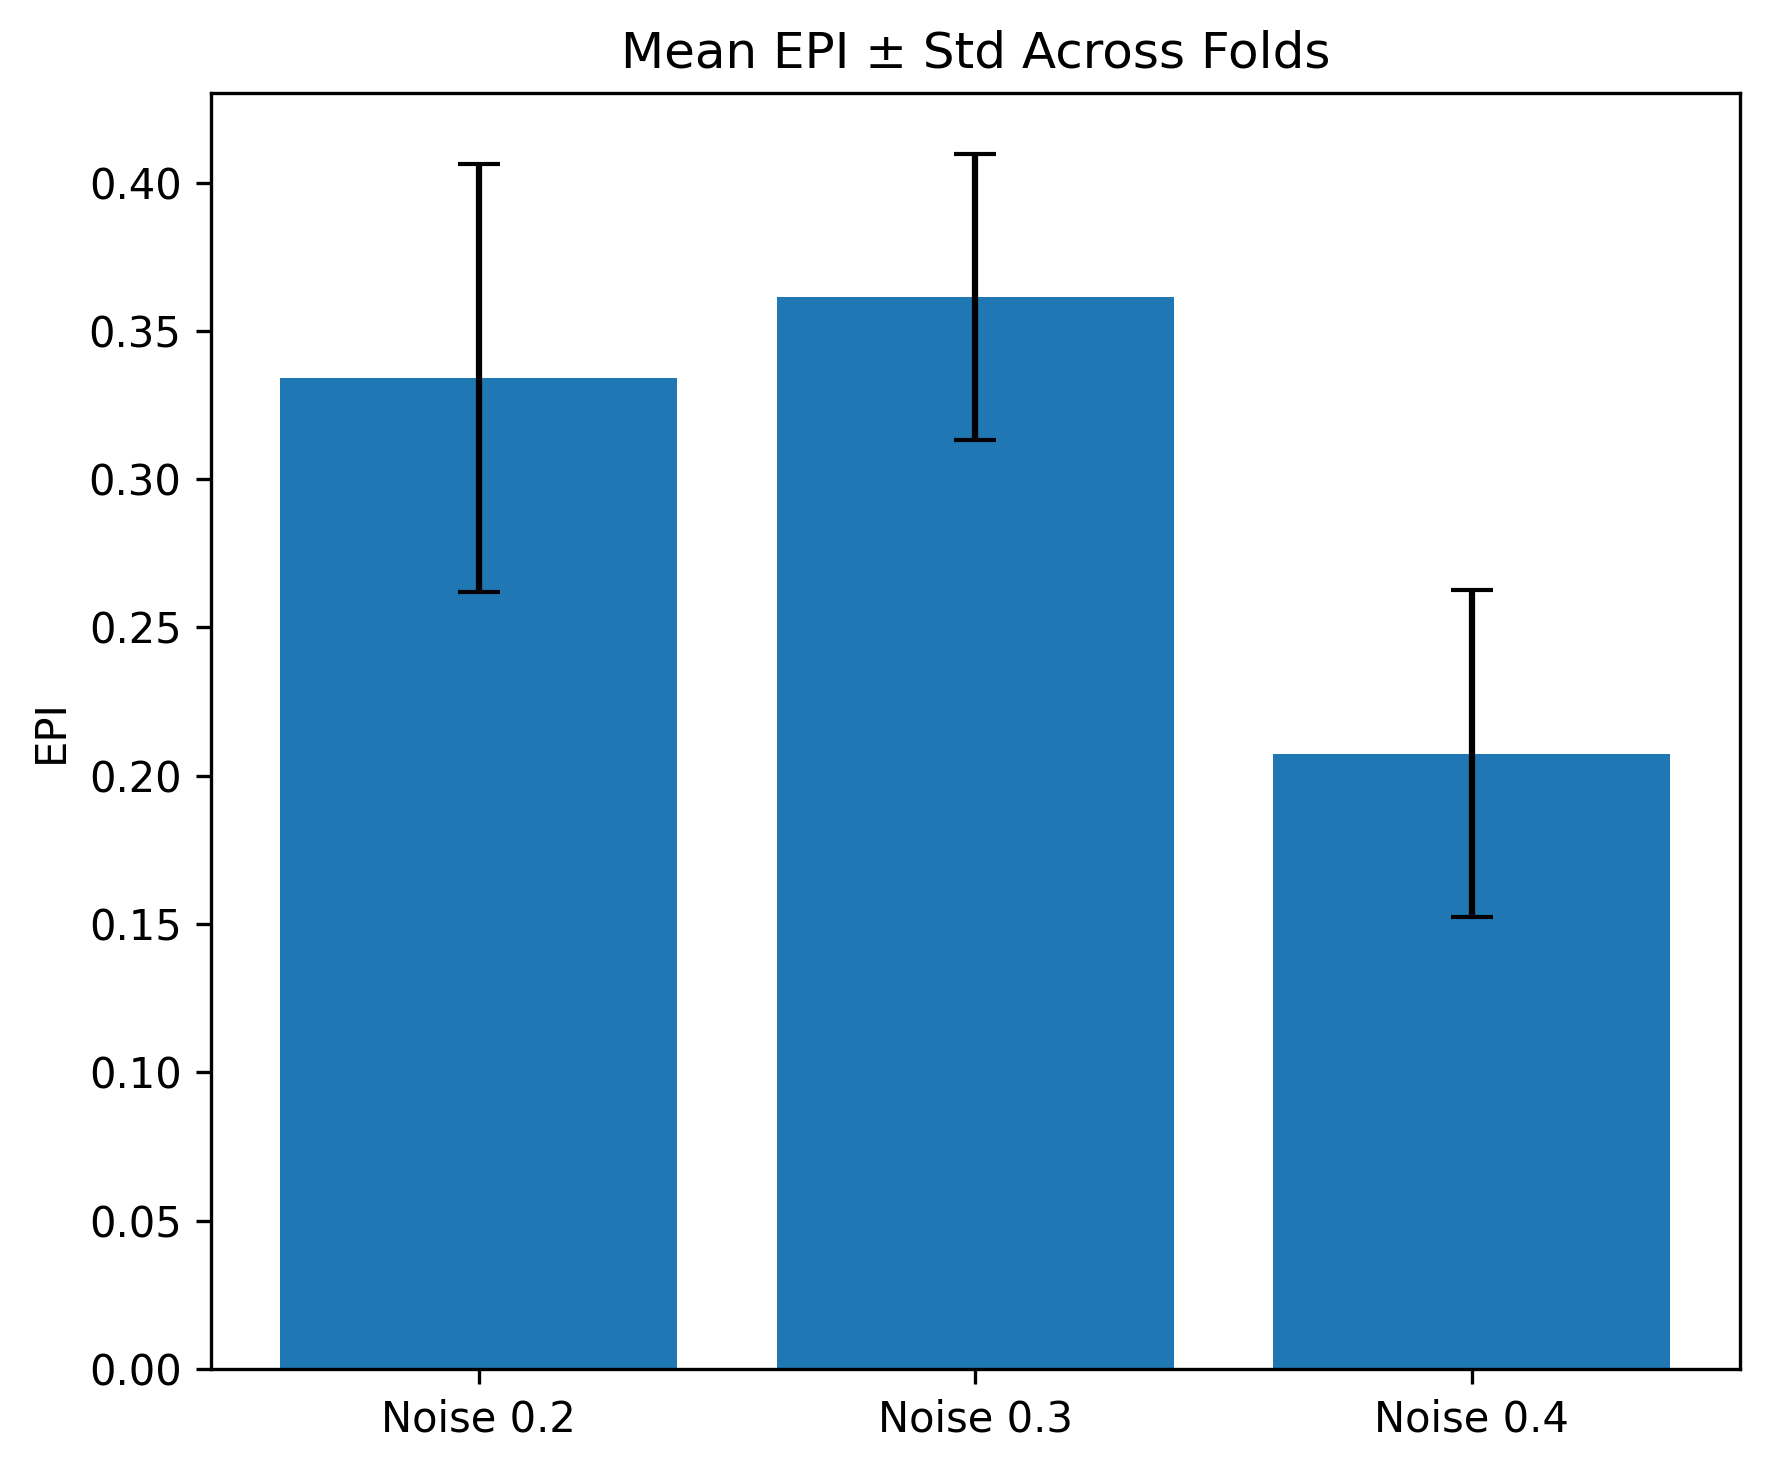

In [7]:
for metric in metrics:
    plt.figure(figsize=(6,5), dpi=300)

    means = []
    stds = []
    labels = []

    for noise, data in all_data.items():
        values = [data[fold][metric] for fold in folds]
        means.append(np.mean(values))
        stds.append(np.std(values))
        labels.append(f"Noise {noise}")

    x = np.arange(len(labels))

    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels)
    plt.title(f"Mean {metric} ± Std Across Folds")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

In [8]:
# training vs validation loss

# make a list of the above values for plotting
train_losses = [0.0172, 0.0178, 0.0176, 0.0174, 0.0165]
val_losses = [0.0187, 0.0175, 0.0203, 0.0170, 0.0164]
folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

# take average and std of traing and validation across folds
avg_train_loss = np.mean(train_losses)
avg_val_loss = np.mean(val_losses)
std_train_loss = np.std(train_losses)
std_val_loss = np.std(val_losses)

# print
print(f"Average Training Loss: {avg_train_loss:.4f} ± {std_train_loss:.4f}")
print(f"Average Validation Loss: {avg_val_loss:.4f} ± {std_val_loss:.4f}")

Average Training Loss: 0.0173 ± 0.0004
Average Validation Loss: 0.0180 ± 0.0014
